# Plan analysis example with QI and DVH.


This notebook-style script shows how to compute and visualize Quality Indicators (QI)
and Dose-Volume Histograms (DVHs) for a simple proton plan.

In [1]:
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    calc_dose_influence,
    fluence_optimization,
    generate_stf,
    load_tg119,
    plot_slice,
    settings,
)
from pyRadPlan.analysis import DVHCollection, QICollection, DX, VX, Mean
from pyRadPlan.optimization.objectives import SquaredDeviation, SquaredOverdosing, MeanDose

# Prefer GPU when available, fall back to numpy on CPU
settings.xp.prefer_gpu = True
settings.xp.preferred_cpu_array_backend = "numpy"
logging.basicConfig(level=logging.INFO)

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ct, cst = load_tg119()
pln = IonPlan(radiation_mode="protons", machine="Generic")
pln.prop_opt = {"solver": "scipy"}
stf = generate_stf(ct, cst, pln)
dij = calc_dose_influence(ct, cst, stf, pln)

cst.vois[0].objectives = [SquaredOverdosing(priority=10.0, d_max=1.0)]  # OAR
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
cst.vois[2].objectives = [
    MeanDose(priority=1.0, d_ref=0.0),
    SquaredOverdosing(priority=10.0, d_max=2.0),
]  # BODY

fluence = fluence_optimization(ct, cst, stf, dij, pln)
# Result
result = dij.compute_result_ct_grid(fluence)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:359: RuntimeWarning: divide by zero encountered in divide
  (p_min - self._source_points) / self._ray_vec,  # alpha to "near" plane
C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:360: RuntimeWarning: divide by zero encountered in divide
  (p_max - self._source_points) / self._ray_vec,


Beam: 100%|██████████| 1/1 [00:00<00:00,  3.55b/s]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid not set. Using default resolution.


...

INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:176 Objective function evaluations, avg. time: 0.00458444 +/- 0.000180565 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:176 Derivative evaluations, avg. time: 0.00695452 +/- 0.000258273 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 2.20921 s


## Quick single QIs

In [3]:
D2 = DX.compute_from(quantity=result["physical_dose"], mask=cst.vois[1].mask, ref_vol=2)
V3Gy = VX.compute_from(quantity=result["physical_dose"], mask=cst.vois[1].mask, ref_dose=3.0)
mean = Mean.compute_from(quantity=result["physical_dose"], mask=cst.vois[1].mask)

print(f"{D2.metric}: {D2.value:.2f} {D2.unit:~}")
print(f"{V3Gy.metric}: {V3Gy.value:.2f} {V3Gy.unit:~}")
print(f"{mean.metric}: {mean.value:.2f} {mean.unit:~}")

D2: 3.04 Gy
V3Gy: 37.26 %
mean: 2.96 Gy


## QI collection for multiple structures and metrics

In [4]:
qi_collection = QICollection.from_structure_set(
    cst=cst,
    dose=result["physical_dose"],
    ref_doses=[2],
    ref_vols=[50],
)

# print max dose to target
target_name = cst.vois[1].name
qi = qi_collection[target_name]["max"]
print(f"{target_name} {qi.metric}: {qi.value:.2f} {qi.unit:~}")

OuterTarget max: 3.10 Gy


<Axes: title={'center': 'Quality Indicators'}>

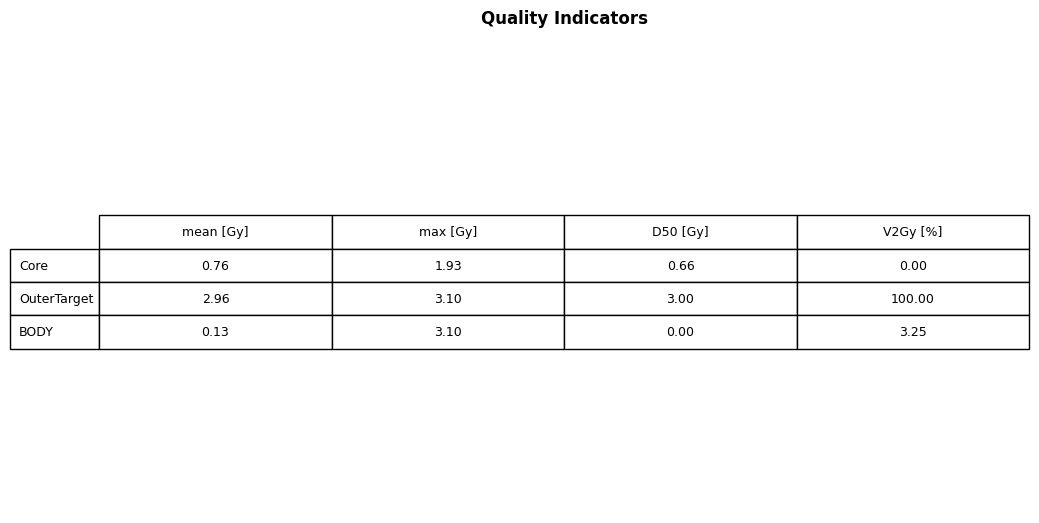

In [5]:
# Plot as table
qi_collection.plot(metrics=["mean", "max", "D50", "V2Gy"])

## DVH example

<Axes: xlabel='Dose [Gy]', ylabel='Volume [%]'>

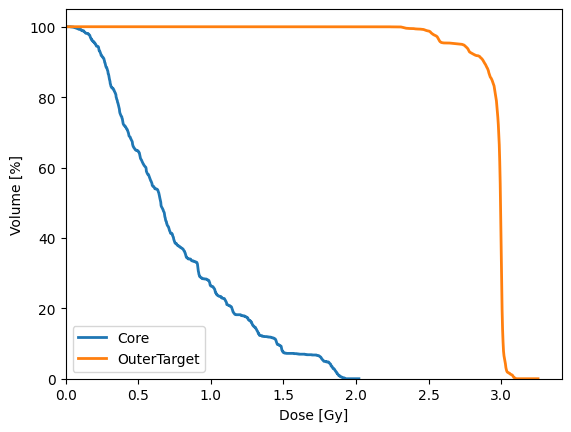

In [6]:
dvh_collection = DVHCollection.from_structure_set(cst=cst, dose=result["physical_dose"])

# Plot DVHs for target and OAR
target_name = cst.vois[1].name
oar_name = cst.vois[0].name
dvh_collection.plot(structures=[target_name, oar_name], line_width=2, plot_legend=True)

## Optional: slice visualization

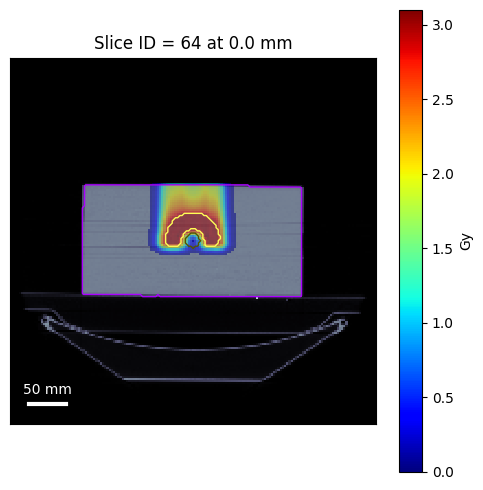

In [7]:
view_slice = int(np.round(ct.size[2] / 2))
plot_slice(
    image_volume=ct,
    cst=cst,
    overlay=result["physical_dose"],
    view_slice=view_slice,
    plane="axial",
    overlay_unit="Gy",
)